In [1]:
import warnings
warnings.filterwarnings("ignore")

import gzip
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

from dadapy.metric_comparisons import MetricComparisons
from dadapy.plot import plot_inf_imb_plane
from dadapy._utils import utils

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def check_for_equal_rows(matrix):
    for i in range(len(matrix)):
        for j in range(i + 1, len(matrix)):
            if np.array_equal(matrix[i], matrix[j]):
                print(f"Equal rows found: {i} and {j}")
                return True
    return False


# Example matrix
matrix = np.random.rand(5, 3)
print(check_for_equal_rows(matrix))
matrix = np.zeros((5, 3))
print(check_for_equal_rows(matrix))

False
Equal rows found: 0 and 1
True


# Atoms with highest KL Divergence

In [3]:
KLD_Coul_Mat = np.loadtxt("./computed_data/pos_cm-kld.txt")

delta_E_s1 = np.loadtxt("./traj_data/EneGap_S1.txt")
delta_E_s0 = np.loadtxt("./traj_data/EneGap_S0.txt")

print(delta_E_s1.shape, delta_E_s0.shape)

with gzip.GzipFile(f"./computed_data/pos_coul_matrix_S0.npy.gz", "rb") as f:
    Coul_Mat_S0 = np.load(f)
with gzip.GzipFile(f"./computed_data/pos_coul_matrix_S1.npy.gz", "rb") as f:
    Coul_Mat_S1 = np.load(f)

print(Coul_Mat_S0.shape, Coul_Mat_S1.shape)

(234664,) (163190,)
(163190, 47, 47) (234664, 47, 47)


In [4]:
print(np.min(KLD_Coul_Mat), np.max(KLD_Coul_Mat))

0.0 0.4521396900638913


In [5]:
# KLD elements involved in pyramidalization
print(KLD_Coul_Mat[23, 22], KLD_Coul_Mat[23, 21], KLD_Coul_Mat[23, 19])

# KLD elements involved in the dihedral/double bond
print(
    KLD_Coul_Mat[22, 21],
    KLD_Coul_Mat[22, 19],
    KLD_Coul_Mat[22, 3],
    KLD_Coul_Mat[21, 19],
    KLD_Coul_Mat[21, 3],
    KLD_Coul_Mat[19, 3],
)

0.16941535670063115 0.11125048440513108 0.1407763698329284
0.24122512933004392 0.11019545452568029 0.2437438052173898 0.16556397532987538 0.1124466003980931 0.1728127551538936


# Get relevant atom indices

In [6]:
nprocs = 16

# Define the desired fixed cutoff value
## choose a cutoff for values in KLD Matrix to be considered "relevant"
cutoff = 0.40

# --- Method 1: Using np.triu to mask and then np.where (Recommended) ---

# Create a boolean mask for the upper triangle (excluding the diagonal, k=1)
# Ensures we only consider elements where row index < column index
upper_triangle_mask = np.triu(np.ones_like(KLD_Coul_Mat, dtype=bool), k=1)

# Create a boolean mask for values above the cutoff
value_mask = KLD_Coul_Mat > cutoff

# Combine the masks: Select elements that are BOTH in the upper triangle AND above the cutoff
combined_mask = upper_triangle_mask & value_mask

# Find the indices (row, col) where the combined mask is True
rows, cols = np.where(combined_mask)

# --- Alternative Method 2: Using np.triu_indices (Also efficient) ---
# # Get indices of the upper triangle (excluding diagonal, k=1)
# n_rows = KLD_Coul_Mat.shape[0]
# rows_upper, cols_upper = np.triu_indices(n_rows, k=1)
#
# # Get the values from the upper triangle
# values_upper = KLD_Coul_Mat[rows_upper, cols_upper]
#
# # Find which of these upper triangle values are above the cutoff
# indices_above_cutoff = np.where(values_upper > cutoff)[0] # np.where returns a tuple, take the first element
#
# # Select the corresponding row and column indices
# rows = rows_upper[indices_above_cutoff]
# cols = cols_upper[indices_above_cutoff]
# ---------------------------------------------------------------------


# Create a list of (row, col) tuples representing the unique pairs (i < j)
# rows correspond to the first variable set index ('i')
# cols correspond to the second variable set index ('j')
idx_Coul_Mat = list(zip(rows, cols))

# Print the pairs and their values (for verification)
print(f"Unique pairs (row < col) with KLD > {cutoff}:")
if not idx_Coul_Mat:
    print("No pairs found above the cutoff in the upper triangle.")
else:
    for r, c in idx_Coul_Mat:
        # Use the found indices directly
        print(f"({r}, {c}): {KLD_Coul_Mat[r, c]:.4f}")

# Get the individual relevant indices in separate lists
# 'i' indices (rows)
iatoms_Coul_Mat = rows.tolist()
# 'j' indices (columns)
jatoms_Coul_Mat = cols.tolist()

print("\nRow indices (i):", iatoms_Coul_Mat)
print("Column indices (j):", jatoms_Coul_Mat)
print("Number of chosen features:", len(iatoms_Coul_Mat))

Unique pairs (row < col) with KLD > 0.4:
(2, 27): 0.4012
(8, 22): 0.4062
(8, 27): 0.4146
(8, 28): 0.4225
(8, 30): 0.4307
(8, 39): 0.4011
(8, 40): 0.4150
(8, 44): 0.4082
(10, 28): 0.4105
(10, 30): 0.4295
(10, 39): 0.4125
(10, 40): 0.4133
(11, 27): 0.4378
(11, 28): 0.4224
(11, 30): 0.4484
(11, 32): 0.4111
(11, 39): 0.4274
(11, 40): 0.4521
(12, 27): 0.4289
(12, 28): 0.4213
(12, 30): 0.4456
(12, 32): 0.4079
(12, 39): 0.4250
(12, 40): 0.4483
(13, 27): 0.4100
(13, 28): 0.4253
(13, 30): 0.4415
(13, 32): 0.4147
(13, 39): 0.4292
(13, 40): 0.4398
(14, 28): 0.4051
(16, 27): 0.4397
(16, 28): 0.4137
(16, 30): 0.4434
(16, 32): 0.4041
(16, 39): 0.4138
(16, 40): 0.4478
(17, 27): 0.4065
(17, 28): 0.4232
(17, 30): 0.4400
(17, 32): 0.4126
(17, 39): 0.4261
(17, 40): 0.4349
(20, 27): 0.4277
(20, 28): 0.4131
(20, 30): 0.4404
(20, 39): 0.4160
(20, 40): 0.4430

Row indices (i): [2, 8, 8, 8, 8, 8, 8, 8, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 14, 16, 16, 16, 16, 

## Load the trajectories

In [7]:
uni_s1 = mda.Universe("./traj_data/rmsfit_traj_S1.xyz")
traj_s1 = uni_s1.trajectory.trajectory

print(len(idx_Coul_Mat), len(traj_s1))

48 234664


In [8]:
## iterate over the trajectory and create a dataset of distances between the relevant atoms for each descriptor
range_random_frames = 20
random_starting_frame = 1  # seed to be reproducible
# random_starting_frame = np.random.randint(1, range_random_frames)
print(random_starting_frame)

# Create a mask to select every n-th element, starting from the random index
mask = np.arange(random_starting_frame, len(traj_s1), range_random_frames)

desired_output_size = len(traj_s1)
if len(mask) != desired_output_size:
    print(len(mask), desired_output_size)
    mask = mask[:desired_output_size]
    print(len(mask))

## dimension of IIB dataset: (total number of time steps, num_relevant_coords from coulomb matrix)
#!# stores the coulomb matrix element between 2 atoms for every frame
s1_Coul_Mat = np.zeros([len(mask), len(idx_Coul_Mat)])
#!# stores the distance between 2 atoms for every frame
s1_Dist_Mat = np.zeros([len(mask), len(idx_Coul_Mat)])

print(s1_Coul_Mat.shape, s1_Dist_Mat.shape)

for tt, frame in enumerate(traj_s1[mask]):
    xyz = frame.positions
    cmat = Coul_Mat_S1[int(frame.time)]
    # print(xyz.shape, cmat.shape)
    for cc, (ii, jj) in enumerate(zip(iatoms_Coul_Mat, jatoms_Coul_Mat)):
        s1_Dist_Mat[tt, cc] = np.linalg.norm(xyz[ii] - xyz[jj])
        s1_Coul_Mat[tt, cc] = cmat[ii, jj]



1
11734 234664
11734
(11734, 48) (11734, 48)


In [9]:
print(mask)

[     1     21     41 ... 234621 234641 234661]


In [10]:
print(delta_E_s1[17] - delta_E_s1[156783])

print(s1_Coul_Mat[4734] - s1_Coul_Mat[10086])

0.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [11]:
# removal of overlapping data points
delta_E_s1_unique = np.unique(delta_E_s1[mask], axis=0)
print(delta_E_s1[mask].shape, delta_E_s1_unique.shape)

s1_Coul_Mat_unique = np.unique(s1_Coul_Mat, axis=0)
print(s1_Coul_Mat.shape, s1_Coul_Mat_unique.shape)

(11734,) (11669,)
(11734, 48) (11670, 48)


In [12]:
def drop_any_duplicate_indices_both(A, B):
    """
    Remove rows (by index) from BOTH A and B if that index belongs to a duplicate
    group in EITHER A or B. Keeps alignment and makes both outputs same length.

    A, B: arrays with same first dimension (n_rows).
    Returns: A_filt, B_filt, keep_mask
    """
    A = np.asarray(A)
    B = np.asarray(B)
    if A.shape[0] != B.shape[0]:
        raise ValueError(
            f"A and B must have same n_rows. Got {A.shape[0]} vs {B.shape[0]}"
        )

    # duplicate group membership in each array:
    # duplicated indices are those that appear more than once; keep_mask should be True
    # only for rows that are unique in BOTH arrays.
    _, invA, cntA = np.unique(A, axis=0, return_inverse=True, return_counts=True)
    _, invB, cntB = np.unique(B, axis=0, return_inverse=True, return_counts=True)

    print(invA.shape, invA, cntA[cntA > 1], cntA[cntA > 1].shape)
    print(invB.shape, invB, cntB[cntB > 1], cntB[cntB > 1].shape)
    is_dup_in_A = cntA[invA] > 1
    is_dup_in_B = cntB[invB] > 1

    print(is_dup_in_A[is_dup_in_A].shape)
    print(np.argwhere(is_dup_in_A).reshape(-1))

    print(is_dup_in_B[is_dup_in_B].shape)
    print(np.argwhere(is_dup_in_B).reshape(-1))

    keep_mask = ~(is_dup_in_A | is_dup_in_B)

    return A[keep_mask], B[keep_mask], keep_mask


delta_E_s1_f, s1_Coul_Mat_f, keep = drop_any_duplicate_indices_both(
    delta_E_s1[mask], s1_Coul_Mat
)

print(keep.shape)
print("before:", delta_E_s1[mask].shape, s1_Coul_Mat.shape)
print("after: ", delta_E_s1_f.shape, s1_Coul_Mat_f.shape)


#!# Normalize the matrices: VERY IMPORTANT
print(s1_Coul_Mat_f.min(axis=0), s1_Coul_Mat_f.max(axis=0))
s1_Coul_Mat_f = s1_Coul_Mat_f / s1_Coul_Mat_f.max(axis=0)
print(s1_Coul_Mat_f.min(axis=0), s1_Coul_Mat_f.max(axis=0))

(11734,) [11653  9696 11499 ...   897   209   231] [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] (65,)
(11734,) [10616 10625 10403 ... 10783 11023 11163] [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2] (64,)
(130,)
[  837  4734  4735  4736  4737  4738  4739  4740  4741  4742  4743  4744
  4745  4746  4747  4748  4749  4750  4751  4752  4753  4754  4755  4756
  4757  4758  4759  4760  4761  4762  4763  4764  4765  4766  4767  4768
  4769  4770  4771  4772  4773  4774  4775  4776  4777  4778  4779  4780
  4781  4782  4783  4784  4785  4786  4787  4788  4789  4790  4791  4792
  4793  4794  4795  4796  4797  8258 10086 10087 10088 10089 10090 10091
 10092 10093 10094 10095 10096 10097 10098 10099 10100 10101 10102 10103
 10104 10105 10106 10107 10108 10109 10110 10111 10112 10113 10114 10115
 10116 10117 10118 10119 10120 

# Coulomb Matrix Elements

In [13]:
## Compute IIB over the dataset
d_s1_CM = MetricComparisons(
    s1_Coul_Mat_f, maxk=s1_Coul_Mat_f.shape[0] - 1, n_jobs=nprocs
)
labels = ["x{}".format(i) for i in range(len((idx_Coul_Mat)))]
coord_list = [np.arange(i) for i in range(1, len(idx_Coul_Mat) + 1)]

d_s1_CM.remove_identical_points()

# compute the information imbalances
imbalances = d_s1_CM.return_inf_imb_full_selected_coords(coord_list)
# plot_inf_imb_plane(imbalances, coord_list)
print("=====================")
print(imbalances)

No identical identical points were found
total number of computations is:  48
total number of computations is:  48


/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(


[[2.10e-01 1.10e-01 8.72e-02 5.87e-02 5.76e-02 5.13e-02 5.07e-02 1.82e-02
  7.64e-03 6.00e-03 4.77e-03 4.22e-03 2.67e-03 1.91e-03 1.68e-03 1.29e-03
  1.15e-03 1.04e-03 9.04e-04 7.56e-04 7.12e-04 6.07e-04 5.58e-04 5.30e-04
  5.10e-04 4.67e-04 4.56e-04 4.13e-04 3.96e-04 3.89e-04 3.79e-04 3.50e-04
  2.82e-04 2.73e-04 2.50e-04 2.45e-04 2.41e-04 2.38e-04 2.31e-04 2.28e-04
  2.22e-04 2.19e-04 2.17e-04 2.09e-04 1.95e-04 1.89e-04 1.80e-04 1.72e-04]
 [6.21e-01 4.12e-01 3.16e-01 2.04e-01 1.92e-01 1.67e-01 1.63e-01 1.57e-01
  3.65e-02 2.38e-02 1.98e-02 1.82e-02 1.15e-02 5.46e-03 4.86e-03 4.04e-03
  3.77e-03 3.49e-03 3.12e-03 1.78e-03 1.64e-03 1.24e-03 1.16e-03 1.15e-03
  1.10e-03 8.88e-04 8.69e-04 7.13e-04 6.93e-04 6.94e-04 6.51e-04 5.83e-04
  3.32e-04 3.26e-04 2.93e-04 2.89e-04 2.86e-04 2.83e-04 2.69e-04 2.63e-04
  2.56e-04 2.52e-04 2.49e-04 2.30e-04 2.03e-04 1.93e-04 1.81e-04 1.72e-04]]


## Miscellaneous Testing

In [14]:
tmp_dd, tmp_di = utils.compute_nn_distances(
    s1_Coul_Mat_f, maxk=d_s1_CM.maxk, n_jobs=nprocs
)

zero_dists = np.sum(tmp_dd[:, 1:] <= 1.01 * np.finfo(np.float32).eps)
print(zero_dists)

# print(check_for_equal_rows(s1_Coul_Mat))
# print(check_for_equal_rows(delta_E_s0))
# print(check_for_equal_rows(delta_E_s1))
# print(check_for_equal_rows(fosc_s0))
# print(check_for_equal_rows(fosc_s1))

0


In [15]:
indices = np.nonzero(tmp_dd[:, 1:] < np.finfo(np.float32).eps)
print(indices)

print(indices[0].shape[0])

dims_test = indices[0].shape[0]
test_mat = np.zeros((dims_test, dims_test))
print(test_mat.shape)
for jj, jds in enumerate(indices[0]):
    for ii,  ids in enumerate(indices[0]):
        test_mat[jj, ii] = np.linalg.norm(s1_Coul_Mat_f[jds] - s1_Coul_Mat_f[ids])
        # print(ids)

print(test_mat)

(array([], dtype=int64), array([], dtype=int64))
0
(0, 0)
[]


## $\Delta E$ target ranks - Coulomb Matrix Elements

In [16]:
d_s1_dE = MetricComparisons(
    delta_E_s1_f[:, np.newaxis], maxk=delta_E_s1_f.shape[0] - 1, n_jobs=nprocs
)
d_s1_dE.compute_distances(maxk=(delta_E_s1_f.shape[0] - 1))
target_rank_dE_s1 = d_s1_dE.dist_indices

In [18]:
best_sets_dE_s1, best_imbs_dE_s1, all_imbs_dE_s1 = (
    d_s1_CM.greedy_feature_selection_target(
        target_ranks=target_rank_dE_s1, n_coords=25, n_best=3, k=15
    )
)

total number of computations is:  48


/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(
/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(
/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distanc

total number of computations is:  138
total number of computations is:  136
total number of computations is:  133
total number of computations is:  130
total number of computations is:  126
total number of computations is:  124
total number of computations is:  121
total number of computations is:  118
total number of computations is:  115
total number of computations is:  113
total number of computations is:  109
total number of computations is:  106
total number of computations is:  102
total number of computations is:  100
total number of computations is:  96
total number of computations is:  93
total number of computations is:  90
total number of computations is:  87
total number of computations is:  85
total number of computations is:  82
total number of computations is:  79
total number of computations is:  75
total number of computations is:  72
total number of computations is:  70


In [19]:
# these are the optimum sets of each n-plet size:
print(best_sets_dE_s1)

# for each optimum variable set of increasing size, these are the information imbalances
# [full-->reduced, reduced --> full]
print(best_imbs_dE_s1)

[[5], [2, 3], [1, 2, 5], [1, 2, 3, 5], [0, 1, 2, 3, 5], [1, 2, 3, 5, 7, 9], [1, 2, 3, 34, 5, 7, 9], [1, 2, 3, 34, 5, 7, 11, 31], [0, 1, 2, 3, 34, 5, 7, 11, 31], [0, 1, 2, 3, 34, 5, 37, 7, 11, 31], [0, 1, 2, 3, 34, 5, 4, 7, 9, 18, 30], [0, 1, 2, 3, 34, 5, 4, 7, 6, 9, 18, 30], [0, 1, 2, 3, 34, 5, 37, 7, 4, 9, 6, 10, 18], [0, 1, 2, 3, 34, 5, 37, 7, 4, 9, 6, 10, 18, 24], [0, 1, 2, 3, 34, 5, 37, 7, 4, 9, 6, 10, 11, 18, 24], [0, 1, 2, 3, 34, 5, 37, 7, 4, 9, 6, 10, 11, 12, 18, 24], [0, 1, 2, 3, 34, 5, 37, 7, 4, 9, 6, 10, 11, 12, 35, 18, 24], [0, 1, 2, 3, 34, 5, 37, 7, 4, 9, 6, 10, 11, 12, 35, 18, 24, 30], [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 18, 24, 30, 34, 35, 37, 43], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 24, 30, 34, 35, 37, 43], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 24, 30, 31, 32, 34, 35, 37], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 24, 30, 31, 32, 34, 35, 37, 43], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 24, 26, 30, 31, 32, 34, 35, 37, 43], [0, 1, 2, 3, 

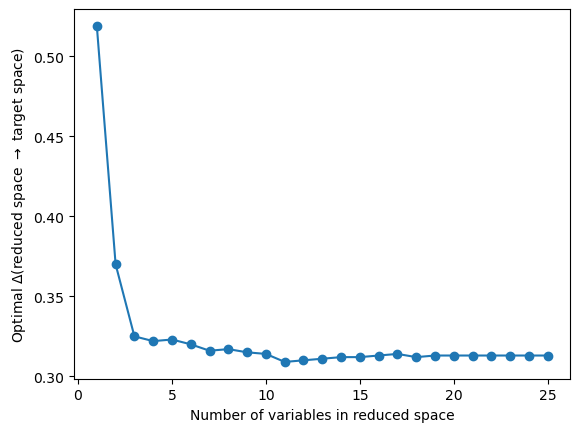

In [20]:
plt.plot(range(1, len(best_imbs_dE_s1) + 1), best_imbs_dE_s1[:, 1], "o-")
plt.ylabel(r"Optimal $\Delta$(reduced space $\rightarrow$ target space)")
plt.xlabel("Number of variables in reduced space")
plt.show()

# S1: Linear Fit - $\Delta E$ and IIB components

In [21]:
# Coul Mat & Dist Mat are symmetric C(i,j) == C(j,i)
#!# Get the relevant IIB coordinates from when the curve sort of plateaus at minimum IIB (i.e., maximum information)
relevant_IIB_delta_E_s1_coords = best_sets_dE_s1[2]

idx_Coul_Mat_arr = np.array(idx_Coul_Mat)
relevant_idxs = idx_Coul_Mat_arr[relevant_IIB_delta_E_s1_coords]
print(relevant_idxs)

target_s1 = delta_E_s1

## Don't normalize since the absolute values are meaningful
# Coul_Mat_S1 = Coul_Mat_S1 / Coul_Mat_S1.max(axis=0)

features_s1 = Coul_Mat_S1[:, relevant_idxs[:, 0], relevant_idxs[:, 1]]
print(features_s1.shape, target_s1.shape)

[[ 8 22]
 [ 8 27]
 [ 8 39]]
(234664, 3) (234664,)


In [22]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    features_s1, target_s1, test_size=0.2
)

# Create the linear regression model
model = LinearRegression(fit_intercept=True, positive=False)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_predicted = model.predict(X_test)

# Calculate the mean squared error (MSE)
mse = mean_squared_error(y_test, y_predicted)
print("Mean Squared Error:", mse)

# Calculate and print R-squared score
r2 = r2_score(y_test, y_predicted)
print("R-squared score:", r2)

# Print the coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Mean Squared Error: 0.05054683972498002
R-squared score: 0.9001929208267506
Coefficients: [-11.07  16.05 -43.74]
Intercept: 7.414323339778212


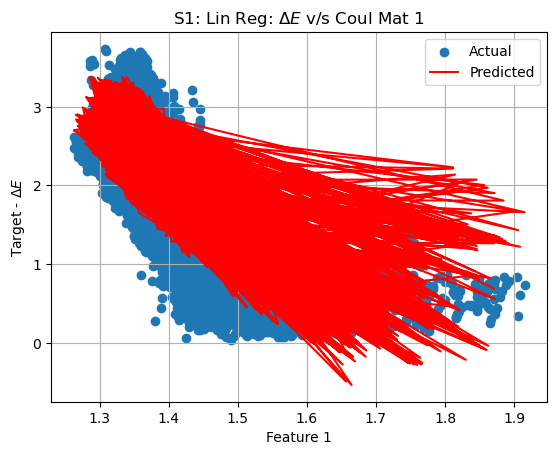

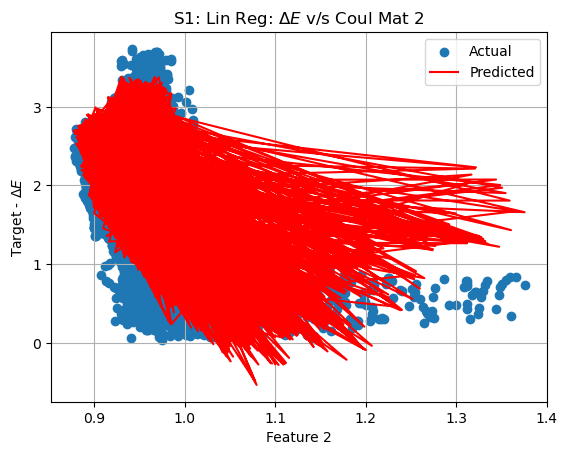

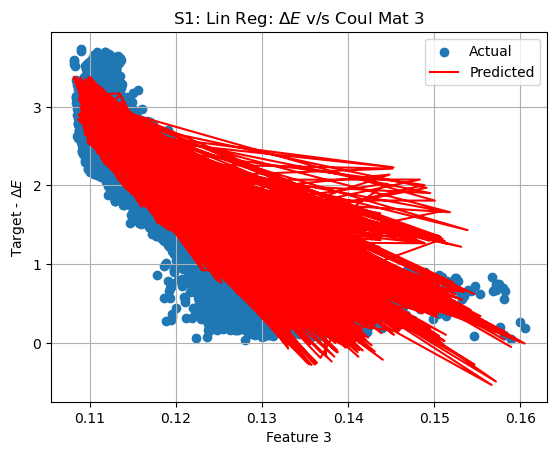

In [23]:
for ii in range(1, X_test.shape[1] + 1):
    plt.scatter(X_test[:, ii - 1], y_test, label="Actual")
    plt.plot(X_test[:, ii - 1], y_predicted, color="red", label="Predicted")
    plt.xlabel(f"Feature {ii}")
    plt.ylabel("Target - $\\Delta E$")
    plt.title(f"S1: Lin Reg: $\Delta E$ v/s Coul Mat {ii}")  # type: ignore
    plt.legend()
    plt.grid(True)
    plt.show()